# 长上下文与长度外推

> 一个模型训练时只见过不超过 4096 个 Token 的序列，部署时却收到一篇 10000 Token 的长文。位置 4096 到 9999 从未出现在训练数据中，模型是否仍能正确处理这些位置上的 Token？
>
> 这就是长度外推（Length Extrapolation）问题：模型需要把训练范围内学到的位置规律应用到更长的序列。位置编码方案不同，可扩展的长度和长文本表现也会不同。
>
> 本章介绍长上下文与长度外推的四组核心内容：
>
> 1. **RoPE 旋转编码**：把位置表示成旋转角度，使 Attention 分数能够反映 Token 之间的相对距离。
>
> 2. **直接外推的失败**：训练范围外的旋转角度超出模型见过的区间，各维度联合相位与相对距离的变化可能导致退化。
>
> 3. **三种外推方法**：Position Interpolation 压缩位置编号，NTK-aware 调整频率基，YaRN 按频率分段处理并缩放 Attention。
>
> 4. **验证与工程**：Needle in a Haystack、RULER 等 benchmark 检验长文能力，手写模块演示 4K→32K；ModelScope 示例从原生 32K Qwen 配置出发做检索，并未完成扩展实验。

下面先定义长度外推并复习位置编码。已经熟悉 Embedding 与位置编码的读者，可以从 RoPE 的旋转机制开始阅读。

## 1. 长度外推

外推是利用已知区间中的规律，推断区间之外的情况。例如固定大气压下，0°C 结冰、约 100°C 沸腾的观察能帮助预测 200°C 水的状态；压力变化会改变判断。

训练只覆盖位置 0–4095 的模型，推理可能收到 10000 Token。新位置的公式能计算，不等于模型能正确处理。位置编码、训练分布和任务共同影响结果。


## 2. 位置编码回顾

Embedding 本身不标记位置：同一个 Token 在位置 0 和 2 查得同一向量，但「我爱你」与「你爱我」词序和含义不同。

不带位置编码和 mask 的 Self-Attention 对置换等变：输入重排，输出也相应重排。分数矩阵被同步置换，并非原坐标上的每个数都保持不变。Causal mask 引入方向结构，显式位置编码则帮助表达距离与顺序。

不同位置编码在超出训练窗口时有不同限制。


In [1]:
# 直观感受：顺序对 attention 的影响
print("句子 A: 我 爱 你")
print("句子 B: 你 爱 我")
print()
print("没有位置编码时：")
print("  '我' 和 '你' 的 attention 分数完全一样——不管谁在前面")
print("  模型分不清 '我爱你' 和 '你爱我'")
print()
print("有位置编码时：")
print("  '我' 在位置 0 和位置 2 有不同的向量 → attention 可以区分")
print()
print("问题来了：训练时最长只见过 4096 个位置，")
print("推理时来了 10000 个位置 → 第 4097 个位置的「标签」长什么样？")

句子 A: 我 爱 你
句子 B: 你 爱 我

没有位置编码时：
  '我' 和 '你' 的 attention 分数完全一样——不管谁在前面
  模型分不清 '我爱你' 和 '你爱我'

有位置编码时：
  '我' 在位置 0 和位置 2 有不同的向量 → attention 可以区分

问题来了：训练时最长只见过 4096 个位置，
推理时来了 10000 个位置 → 第 4097 个位置的「标签」长什么样？


## 3. 三种位置编码的外推能力

| 方案 | 怎么做 | 代表模型 | 能扩展吗？ | 限制 |
|:---|:---|:---|:---|:---|
| 学习绝对位置 | 每个位置训练一个向量 | GPT-2 | 不能直接超出表长 | 1024 项的表没有位置 1024，需要额外扩展方法 |
| 正弦位置编码 | 计算 sin/cos | 原始 Transformer | 新位置的值可计算 | 可计算不保证泛化 |
| RoPE | 旋转 Q/K，相对位移对应相位差 | LLaMA、Qwen、Mistral | 支持扩展方法 | 直接外推仍可能退化 |

RoPE 在这些模型族中很常见，下面拆解可用于频率缩放的结构。


## 4. RoPE：用旋转编码相对位置

第 2 节重温了位置编码的基本问题：Attention 本身不区分「我爱你」与「你爱我」。正弦位置编码的做法是在 Input Embedding 上叠加位置向量，使每个 token 的输入表示携带位置信息。

那么 RoPE（Rotary Position Embedding，旋转位置编码）思路相异。它不修改输入端的 Embedding，而是直接介入 Q 和 K 的点积计算——通过旋转矩阵将相对位置信息“写进”点积结果。

### 4.1 相对位置目标

我们先看 Attention 核心操作是什么。位置 m 的 query 向量 q_m 与位置 n 的 key 向量 k_n 做点积，该值决定两 token 间的 Attention 权重。

为什么需要改造它？因为无位置编码时，q_m 与 k_n 的点积仅取决于语义内容。同一词对无论位于句首或句尾，点积完全一致——因 Embedding 查出的向量只关 token ID，与位置无关。

RoPE 旨在设计操作 f，将位置信息注入 q 和 k，使点积仅依赖**相对位置 m-n**：

$$f(q_m, m) \cdot f(k_n, n) = g(q_m, k_n, \boxed{m - n})$$

为何追求“仅依赖 m-n”？考虑具体实例。句子「我 爱 你」中，「爱」在位置 1，「你」在位置 2，距离为 1。句子「昨天 我 爱 你」中，「爱」移至位置 2，「你」移至位置 3——二者距离仍为 1。两句中「爱」与「你」的语义关系应相同。换句话说，若点积仅依相对距离，固定内容向量时，距离相同的位置贡献一致；实际上下文向量可以变化，模型便学到最基本的平移不变性。

正弦位置编码通过加法注入位置，但加法使信息混杂——q_m 与 k_n 各自含绝对位置 m 和 n，其点积无法干净地只依赖 m-n。RoPE 通过旋转实现此纯净依赖。

### 4.2 二维旋转

先看最简情形：向量仅 2 维。平面上点 (x, y) 逆时针旋转角度 θ，由旋转矩阵表示：

$$R_\theta = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

旋转后结果为：

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = R_\theta \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} x\cos\theta - y\sin\theta \\ x\sin\theta + y\cos\theta \end{bmatrix}$$

旋转不改变向量长度：$\|R_\theta v\| = \|v\|$。这是几何性质，不证明所有语义性质保持不变。

将此应用于 Attention。把位置 m 的查询向量 q_m 旋转与 m 成正比的角度 mθ，位置 n 的键向量 k_n 旋转 nθ，再算点积：

$$(R_{m\theta}\, q_m)^T (R_{n\theta}\, k_n) = q_m^T R_{m\theta}^T R_{n\theta} k_n$$

关键一步利用旋转矩阵两性质：

**性质一**：$R_\alpha^T = R_{-\alpha}$。旋转矩阵转置等于反向旋转——角度取负即可。

**性质二**：$R_{-\alpha} R_\beta = R_{\beta-\alpha}$。先反向转 α°，再正向转 β°，等价于直接转 (β-α)°。

代入得到：

$$q_m^T R_{-\alpha} R_\beta k_n = q_m^T R_{(n-m)\theta}\, k_n$$

等号右端仅出现 $n-m$，不出现单独 m 或 n。m 与 n 的绝对位置抵消，仅剩二者之差。

**这意味着：旋转后 q_m 与 k_n 的点积仅依赖相对位置 (n-m)，与各自绝对位置无关。** 也就是说，相对位置信息被天然编码进 Q 和 K 的点积。

下面用具体数字手动验证。设向量 q = (1, 1) 和 k = (1, 1)，单位旋转角 θ = 15°，位置 m=2，n=5（距离 3）。再算一组 m=10，n=13（距离亦为 3）——若两组点积相同，便验证“仅依赖 m-n”。

In [2]:
import math
import torch

# === 手动验证：旋转后点积只依赖于相对位置 ===
# 设 q = (1, 1), k = (1, 1), θ = 15° = π/12
theta = math.pi / 12  # 15 度

def rotate_2d(v, angle):
    """对一个二维向量施加旋转矩阵"""
    x, y = v[0], v[1]
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    x_new = x * cos_a - y * sin_a
    y_new = x * sin_a + y * cos_a
    return torch.tensor([x_new, y_new])

q = torch.tensor([1.0, 1.0])
k = torch.tensor([1.0, 1.0])

# 情况 A：m=2, n=5 → 距离 = 3
q_rot_A = rotate_2d(q, 2 * theta)
k_rot_A = rotate_2d(k, 5 * theta)
dot_A = torch.dot(q_rot_A, k_rot_A)

# 情况 B：m=10, n=13 → 距离也是 3
q_rot_B = rotate_2d(q, 10 * theta)
k_rot_B = rotate_2d(k, 13 * theta)
dot_B = torch.dot(q_rot_B, k_rot_B)

# 情况 C：m=0, n=3 → 距离也是 3（更极端的对比）
q_rot_C = rotate_2d(q, 0 * theta)
k_rot_C = rotate_2d(k, 3 * theta)
dot_C = torch.dot(q_rot_C, k_rot_C)

# 情况 D：m=2, n=6 → 距离 = 4（不同距离，对照）
q_rot_D = rotate_2d(q, 2 * theta)
k_rot_D = rotate_2d(k, 6 * theta)
dot_D = torch.dot(q_rot_D, k_rot_D)

print("=== 手算验证：旋转后点积只依赖于 m-n ===")
print()
print("q = (1, 1), k = (1, 1), 单位角 θ = 15°")
print()
print("情况 A: m=2, n=5  (距离=3)    → 点积 =", f"{dot_A:.6f}")
print("情况 B: m=10, n=13 (距离=3)   → 点积 =", f"{dot_B:.6f}")
print("情况 C: m=0, n=3  (距离=3)    → 点积 =", f"{dot_C:.6f}")
print("情况 D: m=2, n=6  (距离=4)    → 点积 =", f"{dot_D:.6f}")
print()
print("关键观察：")
print("  1. A、B、C 的 m,n 各自不同，但距离都是 3 → 点积完全相同")
print("  2. D 的距离是 4 → 点积与前三组不同")
print("  3. 验证完毕：点积只取决于 n-m，不取决于 m 和 n 各自的绝对位置")
print()
print("这就是 RoPE 最核心的数学性质。")

# 补充：旋转前后点积的变化
dot_original = torch.dot(q, k)
print(f"\n旋转前：q·k = {dot_original:.4f}")
print(f"旋转后（距离=3）：点积 ≈ {dot_A:.4f}")
print(f"相对位置的差异被编码进了点积的数值变化中")

=== 手算验证：旋转后点积只依赖于 m-n ===

q = (1, 1), k = (1, 1), 单位角 θ = 15°

情况 A: m=2, n=5  (距离=3)    → 点积 = 1.414213
情况 B: m=10, n=13 (距离=3)   → 点积 = 1.414214
情况 C: m=0, n=3  (距离=3)    → 点积 = 1.414214
情况 D: m=2, n=6  (距离=4)    → 点积 = 1.000000

关键观察：
  1. A、B、C 的 m,n 各自不同，但距离都是 3 → 点积完全相同
  2. D 的距离是 4 → 点积与前三组不同
  3. 验证完毕：点积只取决于 n-m，不取决于 m 和 n 各自的绝对位置

这就是 RoPE 最核心的数学性质。

旋转前：q·k = 2.0000
旋转后（距离=3）：点积 ≈ 1.4142
相对位置的差异被编码进了点积的数值变化中


## 5. 从二维推广到 d 维

上节在二维向量验证了旋转编码相对位置的原理。实际 q 和 k 通常为 64 或 128 维。那么如何将二维旋转推广至 d 维？

### 5.1 d 维向量的分组旋转

方案较为直接：将 d 维拆为 d/2 个互不重叠的二维对：

```
对 0: (dim₀, dim₁)    → 在自己的 2D 平面上旋转
对 1: (dim₂, dim₃)    → 在自己的 2D 平面上旋转
...
对 d/2-1: (dim_{d-2}, dim_{d-1}) → 在自己的 2D 平面上旋转
```

每对独立在所属二维平面旋转，各对互不干扰。写成矩阵，d 维旋转矩阵是分块对角矩阵——对角线上有 d/2 个 2×2 小旋转矩阵，其余位置全 0：

```
R = [R_{θ₀}    0      ...         0      ]
    [  0     R_{θ₁}   ...         0      ]
    [ ...    ...     ...         ...     ]
    [  0      0      ...  R_{θ_{d/2-1}}]
```

实际代码不会真构造此 d×d 大矩阵（多数为 0，浪费计算与显存），而是用向量化操作：相邻维度两两分组，每对独立计算旋转。

### 5.2 不同维度的旋转频率

所有维度对采用同速旋转并不可取——那样各对携带相同位置信息，浪费 d 维表达能力。因此 RoPE 为不同维度对分配不同转速。第 i 对单位旋转角为：

$$\theta_i = \frac{1}{10000^{2i/d}}, \quad i = 0, 1, ..., d/2-1$$

我们把数字代入看清差异。i=0 时，每个位置转 1 弧度，训练窗口 4096 个位置累计 4096 × 1 = 4096 弧度；除以一圈 2π ≈ 6.283 弧度，得到约 652 圈。i=31 时，每位置约 0.00013 弧度，4096 个位置累计 4096 × 0.00013 ≈ 0.53 弧度，更准确约 0.546 弧度（31.3°），远小于一圈。也就是说，快慢维度在训练中的“阅历”天差地别。

- **i=0**（第一对，dim₀ 和 dim₁）：θ₀ = 1.0，每个位置转 1 弧度（≈ 57°），转得飞快。训练窗口 4096 个位置相当于转了 652 个完整圈，sin/cos 所有可能的值都见过了。它的职责是区分**紧挨着的**两个位置。
- **i=31**（最后一对，dim₆₂ 和 dim₆₃，d=64 时）：θ₃₁ ≈ 0.00013，每个位置只转约 0.008°，极慢。在 4096 个训练位置内只走了约 0.55 弧度（31°），远不到一圈。它的职责是承载**远距离**的位置关系。

为什么这样设计？这与正弦位置编码的高频/低频设计思路相同，但作用机制不同：正弦方案是不同频率波形叠加出位置向量加在 embedding 上；RoPE 是不同频率旋转直接作用于 Q 和 K，通过点积编码相对距离。

### 5.3 RoPE 施加在 Q 和 K 上的完整流程

现在串起 RoPE 完整计算。给定 token 序列，流程分五步展开。

第一步是 Embedding 与投影：$x_0, x_1, ..., x_{L-1}$ 经过 Embedding 和 Q/K/V 投影矩阵，得到 $q_m = W_Q x_m$，$k_n = W_K x_n$，$v = W_V x$。也就是说，先拿到原始的 Q、K、V 向量。

第二步是分组：每个 q 和 k 按相邻维度两两分组，(dim₀, dim₁) 是第一对，(dim₂, dim₃) 是第二对，以此类推。这样每对就对应一个二维旋转平面。

第三步逐对旋转：位置 m 的 q 第 i 对旋转角度 $m \cdot \theta_i$，位置 n 的 k 第 i 对旋转角度 $n \cdot \theta_i$。用 4.2 节公式逐对计算旋转后坐标，把位置信息写进方向。

第四步做点积：旋转后 q 和 k 做点积。据 4.2 节推导，第 i 对维度的贡献一般含相对角度的 sine 与 cosine 项，整向量点积是各对贡献之和——固定内容向量时，显式位置项仅依赖 $n-m$。

第五步后续不变：softmax + 乘以 V 步骤和标准 Attention 完全相同。与正弦位置编码的结构性区别由此显现：正弦方案位置向量加在 Embedding 上，后续 Q/K 投影混合语义与位置；RoPE 位置信息绕过 Embedding，直接作用于 Q 和 K，通过旋转矩阵精确控制点积中的位置依赖。V（Value）不参与旋转——标准 RoPE 不旋转 V；V 及后续表征仍可能携带上下文位置线索。

下面用代码实现完整 RoPE，并验证其相对位置性质。

In [3]:
# 直接看：不同维度对的旋转速度差多少
import torch
import math

d_k = 64          # 总共 64 维，两两结对 → 32 对
base = 10000      # RoPE 默认 base

pair_indices = torch.arange(0, d_k, 2).float()  # [0, 2, 4, ..., 62]
freqs = 1.0 / (base ** (pair_indices / d_k))

print(f"共 {len(freqs)} 对维度")
print(f"第 0 对（最快）频率: {freqs[0]:.4f}  → 每位置转 {math.degrees(freqs[0]):.1f}°")
print(f"第 16 对（中等）频率: {freqs[16]:.6f}  → 每位置转 {math.degrees(freqs[16]):.4f}°")
print(f"第 31 对（最慢）频率: {freqs[31]:.8f}  → 每位置转 {math.degrees(freqs[31]):.6f}°")

slowest_period = 2 * math.pi / freqs[31]
print(f"\n最慢那对走完一圈需要 {slowest_period:.0f} 个位置")
# → 训练窗口 4096，最慢的指针连一圈都没走完 → 这就是外推的瓶颈


共 32 对维度
第 0 对（最快）频率: 1.0000  → 每位置转 57.3°
第 16 对（中等）频率: 0.010000  → 每位置转 0.5730°
第 31 对（最慢）频率: 0.00013335  → 每位置转 0.007641°

最慢那对走完一圈需要 47117 个位置


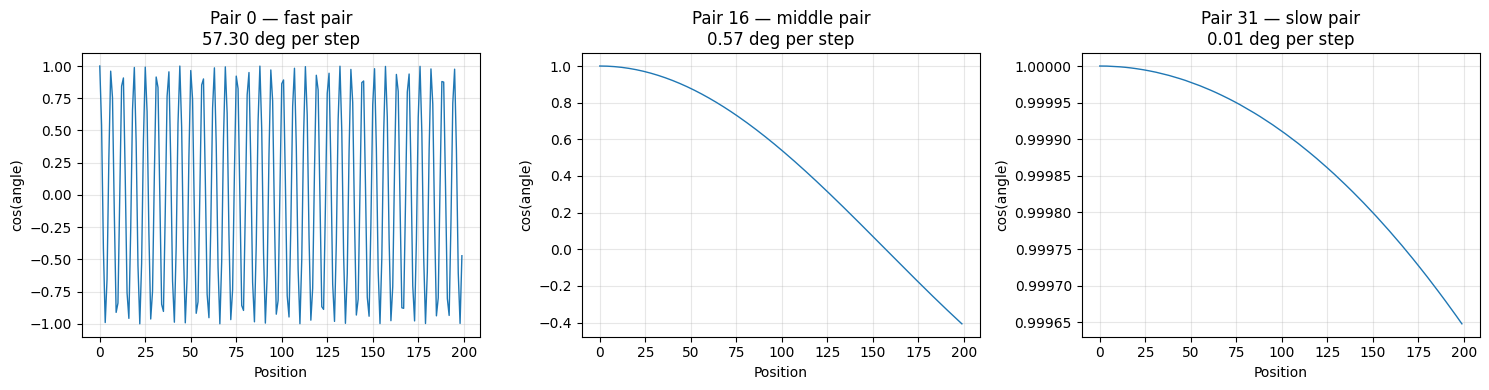

In [4]:
# 画出来：不同维度的指针随位置移动（cos 值）
import torch
import matplotlib.pyplot as plt

seq_len = 200
positions = torch.arange(seq_len).float()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_idx, (pair_idx, label) in enumerate([
    (0, "fast pair"),
    (16, "middle pair"),
    (31, "slow pair")
]):
    theta = positions * freqs[pair_idx]
    ax = axes[ax_idx]
    ax.plot(positions.numpy(), theta.cos().numpy(), linewidth=1)
    ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
    ax.set_title(f'Pair {pair_idx} — {label}\n{math.degrees(freqs[pair_idx]):.2f} deg per step')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# 左边转了好几圈（密集波形）→ 高频 → 区分邻居
# 右边不到半圈（缓慢曲线）→ 低频 → 承载远距离信息


## 6. 直接外推为什么可能失败

训练最多 4096 Token，推理扩到 8192。每个位置的 $m\theta_i$ 都能算出来，但模型质量并不因此得到保证。

### 6.1 快慢维度的区别

以 d=64、base=10000 为例：

| 维度对 | 频率 | 约 4096 位置的角度跨度 | 圈数 | 相位范围 |
|:---|:---|:---|:---|:---|
| i=0 | 1 | 4096 rad | 652 | 很多周期 |
| i=8 | 0.1 | 410 rad | 65 | 很多周期 |
| i=16 | 0.01 | 41 rad | 6.5 | 多个周期 |
| i=24 | 0.001 | 4.1 rad | 0.65 | 部分周期 |
| i=31 | 0.00013335 | 0.546 rad | 0.087 | 小圆弧；sin 约 0–0.519，cos 约 1–0.854 |

周期的比例不等于数值区间 [-1,1] 的比例。快维度遍历了相位角，慢维度只走过很小的圆弧。

### 6.2 超出训练范围

位置 8191 的第 31 对角度约 1.092 rad（62.6°），sin 约 0.888、cos 约 0.460，超出了原来的圆弧。

这说明一种陌生位置特征，却不能证明只有慢维度有问题或快维度能完美外推。Attention 还取决于各维度联合相位、内容向量及新的相对距离。重复出现单个 sin/cos 值，不代表相关组合都已学过。

### 6.3 时钟类比

快维度像已转几百圈的秒针，慢维度像只从 0° 走到 31° 的指针，延伸到 63° 就离开原来的圆弧。这个类比帮助理解频率缩放，只解释了泛化的一部分。下面绘制慢维度训练窗口内外的余弦。


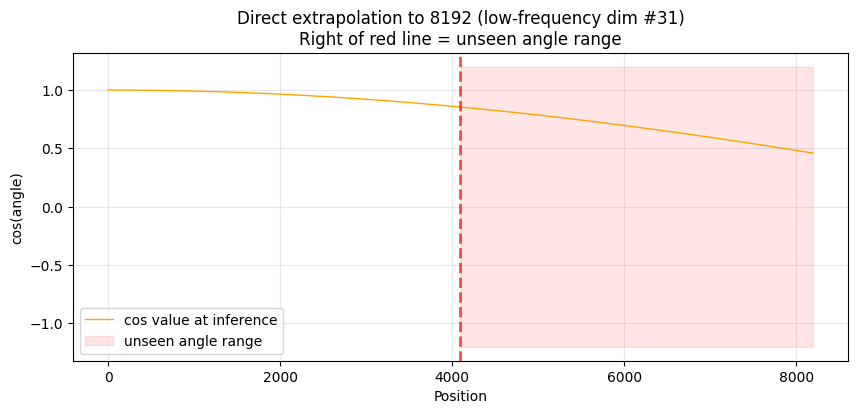

训练时最大角度: 31.3°  →  外推后最大角度: 62.6°  →  超出 31.3°


In [5]:
# 直接外推的问题：低频维度在训练窗口外角度超标
import torch
import matplotlib.pyplot as plt
import math

train_len, extrap_len = 4096, 8192
slow_pair = 31

positions_train = torch.arange(train_len).float()
positions_extrap = torch.arange(extrap_len).float()
theta_train = positions_train * freqs[slow_pair]
theta_extrap = positions_extrap * freqs[slow_pair]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(positions_extrap.numpy(), theta_extrap.cos().numpy(),
        linewidth=1, color='orange', label='cos value at inference')
ax.axvline(x=train_len, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.fill_between(range(train_len, extrap_len), -1.2, 1.2,
                alpha=0.1, color='red', label='unseen angle range')
ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
ax.set_title(f'Direct extrapolation to 8192 (low-frequency dim #{slow_pair})\nRight of red line = unseen angle range')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

# 训练时角度 0~{train_deg:.0f}°，外推时到了 {extrap_deg:.0f}°，超出 {over:.0f}°
train_deg = math.degrees(theta_train[-1].item())
extrap_deg = math.degrees(theta_extrap[-1].item())
print(f"训练时最大角度: {train_deg:.1f}°  →  外推后最大角度: {extrap_deg:.1f}°  →  超出 {extrap_deg - train_deg:.1f}°")


## 7. 控制相位范围

扩展方法改变位置到相位的映射，在近程分辨力与长程特征之间取舍。

### 7.1 三种策略

把训练位置看作 0–4095 的门牌号：

- PI 将位置除以扩展倍数。2 倍扩展时，4096→2048、8191→4095.5，相邻位置也更近。
- NTK-aware 增大频率 base，最快一对不变，较慢的维度逐渐压缩更多。
- YaRN 按频段混合原始与插值频率，平滑过渡，并调整 Attention 缩放。它不是简单改 base，也不是每个维度一个 Softmax 温度。

### 7.2 频率视角

原始频率为 $\theta_i=10000^{-2i/d}$。

- PI：用 $m/s$ 代替 m，等效所有频率除以 s。
- 静态 NTK-aware：$b'=b\,s^{d/(d-2)}$，第 i 对频率比为 $s^{-2i/(d-2)}$；i=0 时为 1，最后一对为 1/s。
- YaRN：根据波长 $\lambda_i=2\pi/\theta_i$ 与原始训练窗口，决定保留或插值的频段，并进行过渡和 Attention 缩放。

均匀压缩→差异化压缩→分段插值是一条理解路线，三种方法并不是必须逐步叠加的配置。


## 8. 方法一：Position Interpolation

**论文**: Meta, 2023 — Extending Context Window via Position Interpolation

为什么需要这个方法？目标是把 4096 窗口扩展到 8192，但模型原本只认得 4096 以内的位置编号。因此，核心思路是将位置编号直接**等比例压缩**。

```
目标: 把 4096 窗口扩展到 8192
缩放因子 α = 4096 / 8192 = 0.5

新位置 = 真实位置 × 0.5

真实位置 0    → 给模型的位置 = 0 × 0.5 = 0
真实位置 2048 → 给模型的位置 = 2048 × 0.5 = 1024
真实位置 8191 → 给模型的位置 = 4095.5
真实位置 8192 → 4096（边界示意，已超出 8192 Token 序列）
```

前文 7.1 节的门牌比喻说的就是此操作。换句话说，所有真实号码都除以 2，新号码约落在原窗口的尺度内。例如真实位置 8192 乘以 0.5 得到 4096，刚好是训练边界。

**代价**：所有维度被同等压缩，原本可清楚区分的相邻位置，压缩后距离都变成原来的一半。也就是说，近程分辨力下降，PI 原始方法包含长文本微调，改位置本身不保证精度。

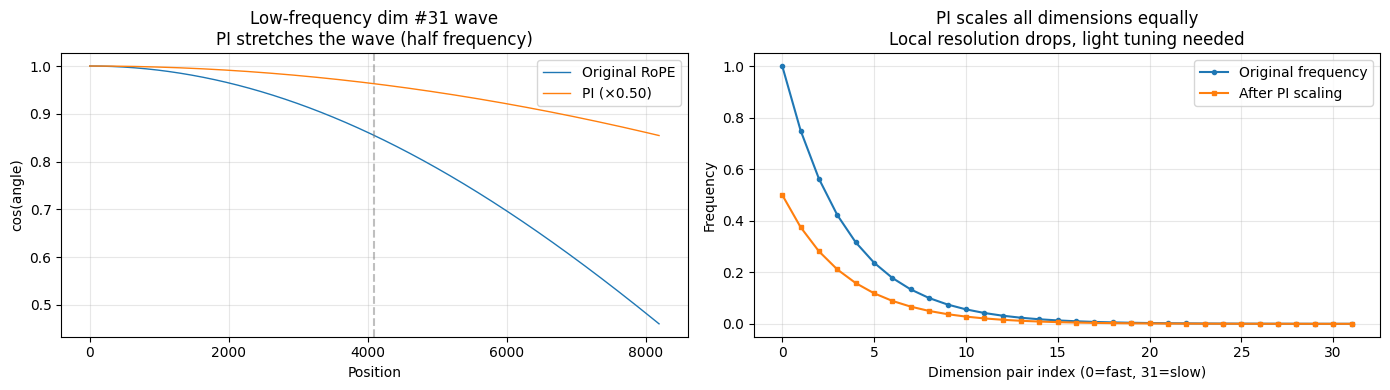

In [6]:
# PI 的实现：位置 × 缩放因子，再正常算 RoPE
import torch
import matplotlib.pyplot as plt

train_len, target_len = 4096, 8192
alpha = train_len / target_len  # 0.5

pair_indices = torch.arange(0, 64, 2).float()
freqs_orig = 1.0 / (10000 ** (pair_indices / 64))
freqs_pi = freqs_orig * alpha

# 原始 RoPE vs PI 压缩后的波形
positions_orig = torch.arange(target_len).float()
angles_orig = positions_orig * freqs_orig[31]
positions_pi = torch.arange(target_len).float() * alpha
angles_pi = positions_pi * freqs_orig[31]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(angles_orig.cos().numpy(), linewidth=1, label='Original RoPE')
axes[0].plot(angles_pi.cos().numpy(), linewidth=1, label=f'PI (×{alpha:.2f})')
axes[0].axvline(x=train_len, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Position'); axes[0].set_ylabel('cos(angle)')
axes[0].set_title(f'Low-frequency dim #{31} wave\nPI stretches the wave (half frequency)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 右：所有维度频率被等比例压缩
axes[1].plot(freqs_orig.numpy(), 'o-', markersize=3, label='Original frequency')
axes[1].plot(freqs_pi.numpy(), 's-', markersize=3, label='After PI scaling')
axes[1].set_xlabel('Dimension pair index (0=fast, 31=slow)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('PI scales all dimensions equally\nLocal resolution drops, light tuning needed')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. 方法二：NTK-aware

**来源**: NTK-Aware Scaled RoPE, bloc97, 2023

PI 的缺点是什么？它对**所有**维度一视同仁压缩。但是第 5 节讲过，不同维度的转速差异很大：

- 快的维度（秒针）：在 4096 位置内已转多圈，各类角度见过 → **最快一对保持不变**
- 慢的维度（时针）：4096 位置内连一圈未走完，未见角度多 → **需要压缩**

因此，NTK-aware 的核心想法是：**慢维度压缩更多；除最快一对外，其他频率也会改变。**

那么如何实现这种差异化压缩？办法是**将 base 从 10000 改大**。这正是 NTK-aware 巧妙的地方。

```
频率公式: freq_i = 1 / base^(2i/d)

base = 10000 → 频率快 → 慢维度也走不完一圈
base = 100000 → 频率变慢 → 慢维度走得更慢 → 同样位置内角度更小 → 不超出训练范围！

而且：
  低 i（快维度）: freq ≈ 1 → 改 base 几乎不影响 ← 快的不用调
  高 i（慢维度）: freq ≈ 1/base → 改 base 影响大 ← 慢的调得多
```

具体来说，base 由 10000 改为 100000，数值扩大到原来的 10 倍（100000 ÷ 10000 = 10）。这恰好实现“快维度不动、慢维度多压”——**单参数改动，自动完成差异化压缩。**
可不改权重测试此公式，但是否可用仍需验证，也可能需要微调。


In [ ]:
# 演示 NTK：改 base 对不同维度的影响
import torch
import matplotlib.pyplot as plt

base_old, scale = 10000, 2
# NTK 公式：新 base = 旧 base × scale^(d/(d-2))
base_new = base_old * (scale ** (64 / 62))

pair_indices = torch.arange(0, 64, 2).float()
freqs_old = 1.0 / (base_old ** (pair_indices / 64))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freqs_old.numpy(), 'o-', markersize=3, label=f'base={base_old}')
axes[0].plot(freqs_new.numpy(), '^-', markersize=3, label=f'base={base_new:.0f}')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('NTK-aware: increase base\nFast dims stay similar, slow dims slow down')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 每个维度的压缩比
ratio = freqs_new / freqs_old
axes[1].bar(range(len(ratio)), ratio.numpy())
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('New frequency / old frequency')
axes[1].set_title('Compression ratio by dimension\nFast dims ~100%, slow dims ~50%')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. 方法三：YaRN

[YaRN](https://arxiv.org/abs/2309.00071)（2023）按频段混合原始频率与 PI 频率：高频接近原始值，低频插值，中间过渡；此外调整 Attention 缩放。这不是各维度分别使用不同 Softmax 温度。

整体 logits 除以更高温度，会让 Softmax 更平缓：

```text
softmax([2, 1, 0.5, 0.25])     ≈ [0.569, 0.209, 0.127, 0.099]
softmax([1, 0.5, 0.25, 0.125]) ≈ [0.398, 0.241, 0.188, 0.173]
```

更尖锐或更平缓都不一定更适合近程或远程。下图是简化的波长分段示意，不是完整 YaRN 实现。后面的模块会明确拒绝尚未实现的 YaRN 分支，避免把 NTK 换名当作 YaRN。LongRoPE、LongRoPE2 是其他超长上下文方案。


In [ ]:
# YaRN 的分段策略：根据波长把维度分成三组
import torch
import matplotlib.pyplot as plt
import math

scale, target_len = 4, 16384
pair_indices = torch.arange(0, 64, 2).float()
base_new = 10000 * (scale ** (64 / 62))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))
wavelengths = 2 * math.pi / freqs_new  # 走完一圈需要的位置数

# 分段阈值
low_bound = target_len / 1.0    # 波长 > 此值 → 低频（需缩放）
high_bound = target_len / 4.0   # 波长 < 此值 → 高频（不缩放）

# ramping: 从 0（不调）平滑过渡到 1（缩放 scale 倍）
smooth = torch.clamp((wavelengths - high_bound) / (low_bound - high_bound), 0.0, 1.0)
dim_scale = (1 - smooth) * 1.0 + smooth * scale

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(32), dim_scale.numpy())
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='No scaling')
axes[0].axhline(y=scale, color='red', linestyle='--', alpha=0.5, label=f'Scale {scale}x')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Scale factor')
axes[0].set_title(f'Band-scaling illustration: keep early pairs, scale later pairs {scale}x\nSmooth transition in the middle')
axes[0].legend()

axes[1].plot(wavelengths.numpy(), 'o-', markersize=3)
axes[1].axhline(y=high_bound, color='green', linestyle='--', alpha=0.5, label=f'High-frequency threshold ({high_bound:.0f})')
axes[1].axhline(y=low_bound, color='red', linestyle='--', alpha=0.5, label=f'Low-frequency threshold ({low_bound:.0f})')
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('Wavelength (tokens per cycle)')
axes[1].set_yscale('log'); axes[1].set_title('Wavelength by dimension\nShort=high freq (unchanged), long=low freq (scaled)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# 简化的频段示意，不是完整 YaRN。


## 11. 三种方法比较

| 方法 | 主要改动 | 微调 |
|:---|:---|:---|
| PI | 统一缩放位置 / 频率 | 原始方法使用微调 |
| 静态 NTK-aware | 增大 base，各频率压缩不同 | 可不改权重测试，质量可能需要适配 |
| YaRN | 按频段混合原始 / 插值频率，缩放 Attention | 取决于配方，原始结果包含微调 |

没有保证 4K→8K 或 4K→32K 的通用 rope_theta 数值。需检查真实 head_dim、旋转维度、已有 scaling 和目标倍数；配置应在旋转模块初始化或重建时生效。

Llama 3 的 base=500000 与长上下文训练配方，不能证明随意把 base 从 10000 改大就能将任意模型从 8K 升到 32K。参考 [Llama 3 技术报告](https://arxiv.org/abs/2407.21783)。下面模块实现 PI 和静态 NTK-aware。


In [ ]:
# 完整代码：一个支持三种外推策略的 RoPE 模块
import torch
import torch.nn as nn

class ExtrapolatableRoPE(nn.Module):
    """教学 RoPE：实现 PI 和静态 NTK，YaRN 尚未实现"""

    def __init__(self, d_k, max_seq_len=4096, base=10000, strategy='ntk'):
        super().__init__()
        self.d_k = d_k
        self.max_seq_len = max_seq_len
        self.base = base
        self.strategy = strategy
        self._update_cache(max_seq_len, base)

    def _update_cache(self, seq_len, base, pi_scale=1.0):
        """重新计算 cos/sin 缓存"""
        positions = torch.arange(seq_len).float() / pi_scale
        freq = 1.0 / (base ** (torch.arange(0, self.d_k, 2).float() / self.d_k))
        angles = positions.unsqueeze(1) * freq.unsqueeze(0)
        cos = angles.cos().repeat_interleave(2, dim=-1)
        sin = angles.sin().repeat_interleave(2, dim=-1)
        self.register_buffer('cos', cos)
        self.register_buffer('sin', sin)

    def set_extrapolation(self, target_len):
        """设置外推目标长度"""
        if target_len <= self.max_seq_len:
            return

        scale = target_len / self.max_seq_len

        if self.strategy == 'pi':
            self._update_cache(target_len, self.base, pi_scale=scale)
        elif self.strategy == 'ntk':
            new_base = self.base * (scale ** (self.d_k / (self.d_k - 2)))
            self._update_cache(target_len, new_base)
        elif self.strategy == 'yarn':
            raise NotImplementedError('YaRN requires bandwise interpolation and attention rescaling.')
        else:
            raise ValueError(f'Unknown strategy: {self.strategy}')

        print(f"外推: {self.max_seq_len} → {target_len} (策略={self.strategy})")

    def forward(self, q, k, offset=0):
        """对 Q 和 K 施加旋转"""
        seq_len = q.shape[-2]
        cos = self.cos[offset:offset + seq_len].to(q.device)
        sin = self.sin[offset:offset + seq_len].to(q.device)

        q_rot = q * cos + (torch.stack([-q[..., 1::2], q[..., ::2]], dim=-1).flatten(-2) * sin)
        k_rot = k * cos + (torch.stack([-k[..., 1::2], k[..., ::2]], dim=-1).flatten(-2) * sin)
        return q_rot, k_rot

# 测试
rope = ExtrapolatableRoPE(d_k=64, max_seq_len=4096, strategy='ntk')
rope.set_extrapolation(32768)

q = torch.randn(1, 1, 100, 64)
k = torch.randn(1, 1, 100, 64)
q_rot, k_rot = rope(q, k)
print(f"Q: {q.shape} → 旋转后: {q_rot.shape}")


## 12. 长上下文的验证方法

把上下文从 4K 扩至 32K 之后，怎么证明模型真“读懂”了长文本？显然不能只靠感觉。

这时候需要客观的检验手段。**探针测试 = 设计仅读懂全文才能答对之题。** 如果模型在长文本中答对，就表明它对远距离 token 的 attention 有效。

检索成功只证明该任务表现，不直接测量 Attention 权重或所有长文能力。


### 12.1 Needle in a Haystack

最经典的探针测试就是 Needle in a Haystack。做法直接：

1. 生成一大段无关文本（“干草堆”），如 32K token 文章
2. 在某位置塞入一句话（“针”），如“密码是 12345”
3. 问模型：“密码是什么？”
4. 若模型能从 32K 文本找到并答对密码 → 表明该位置 attention 良好

把针放在不同位置（开头、中间、结尾），再用不同长度文本（1K、2K、4K、...、32K）逐一组合测试。每种组合测一遍，就能画成热力图观察模型表现。

下面矩阵是模拟结果。需多次测试与不同干扰文档。


In [10]:
# 大海捞针测试矩阵（模拟）：不同长度 × 不同位置
context_lengths = [1024, 2048, 4096, 8192, 16384, 32768]
positions = [0.0, 0.25, 0.5, 0.75, 1.0]  # 针的位置（0=开头, 1=结尾）

# 模拟结果：✅=答对, ❌=答错
results = [
    [True,  True,  True,  True,  True ],   # 1K
    [True,  True,  True,  True,  True ],   # 2K
    [True,  True,  True,  True,  True ],   # 4K
    [True,  True,  True,  True,  True ],   # 8K
    [True,  True,  False, True,  True ],   # 16K — 中间丢了
    [True,  False, False, True,  True ],   # 32K — 前中也丢了
]

print("大海捞针测试矩阵:")
print(f"{'长度':<8}", *[f"{p:.0%}位  " for p in positions])
for i, cl in enumerate(context_lengths):
    print(f"{cl:<8}", *[f"{'✅' if r else '❌'}   " for r in results[i]])
# Lost in the Middle: 中间位置的针更容易丢

大海捞针测试矩阵:
长度       0%位   25%位   50%位   75%位   100%位  
1024     ✅    ✅    ✅    ✅    ✅   
2048     ✅    ✅    ✅    ✅    ✅   
4096     ✅    ✅    ✅    ✅    ✅   
8192     ✅    ✅    ✅    ✅    ✅   
16384    ✅    ✅    ❌    ✅    ✅   
32768    ✅    ❌    ❌    ✅    ✅   


### 12.2 RULER

为什么需要 RULER？因为大海捞针测试只能测“找一句话”的能力，不够全面。RULER 则设计了更多任务，能更完整地检查模型的长上下文本领。

| 测试 | 做什么 | 为什么更难 |
|------|--------|----------|
| **多针召回** | 藏 3 个不同的信息，问 3 次 | 需要同时在多处保持 attention |
| **多跳推理** | 开头说 A=1，结尾说 B=A+1，问 B | 需要把两个远距离信息组合起来推理 |
| **变量追踪** | 跟踪一个值在文章中的多次变化 | 需要更新记忆 |
| **词频统计** | 数某个词在全文出现了几次 | 需要遍历全文并计数 |

**多跳推理最暴露问题**：
```
文章 10% 位置: "公司 A 的营收是 100 亿"
文章 90% 位置: "公司 B 的营收是 A 的 2 倍"
问: "公司 B 的营收是多少？"

模型需要：
  1. 找到 10% 位置的信息 → 100 亿
  2. 找到 90% 位置的信息 → 2 倍
  3. 组合推理 → 200 亿
```

这比单纯“找一句话”要难得多。为什么？因为它要求模型同时对文章开头和结尾保持精确的 attention，才能把两处信息连起来。

In [11]:
# 多跳推理探针示例：需要同时记住多个远距离信息
print("=== 多跳推理探针（模拟）===")
print(f"文章: 32K tokens")
print(f"  5%  位置: 苹果 5 元/个")
print(f"  50% 位置: 小明买 3 个")
print(f"  95% 位置: 满 10 减 2")
print(f"  问题: 小明付多少？ → 答案: 5×3=15, 满10减2 = 13 元")
print(f"\n需要 5%→50%→95% 三次跳转，缺一个就答错")
# 答 15 元 → 漏了结尾的优惠信息
# 答不知道 → 一个信息都没找到

=== 多跳推理探针（模拟）===
文章: 32K tokens
  5%  位置: 苹果 5 元/个
  50% 位置: 小明买 3 个
  95% 位置: 满 10 减 2
  问题: 小明付多少？ → 答案: 5×3=15, 满10减2 = 13 元

需要 5%→50%→95% 三次跳转，缺一个就答错


### 12.3 PPL 曲线

我们怎么知道模型在长文本里是否跟丢了？一个直接指标是困惑度。Perplexity (PPL) 就是困惑度，越低越好，越低表示模型对下一 token 越“有把握”。

那么怎么测？最直接的测试是喂同篇长文给模型，看训练窗口边界（4096）处 PPL 是否突然上涨。

需在相同语料和协议下比较 PPL，不能把自信等同正确。下方曲线是构造示意，不是方法跑分。


In [ ]:
# 模拟 PPL 曲线：不同外推方案在窗口边界外的表现
import torch
import matplotlib.pyplot as plt

lengths = torch.linspace(512, 32768, 100)
ppl_none, ppl_pi, ppl_ntk = [], [], []

for L in lengths:
    if L <= 4096:
        ppl_none.append(10.0); ppl_pi.append(10.0); ppl_ntk.append(10.0)
    else:
        over = (L - 4096) / 4096
        ppl_none.append(10 + 100 * over**1.5)   # 直接爆炸
        ppl_pi.append(10 + 8 * over**0.8)         # 缓慢涨
        ppl_ntk.append(10 + 3 * over**0.5)        # 几乎不涨

plt.figure(figsize=(10, 5))
plt.plot(lengths.numpy(), ppl_none, label='No extrapolation', linewidth=2, color='red')
plt.plot(lengths.numpy(), ppl_pi, label='PI', linewidth=2, color='orange')
plt.plot(lengths.numpy(), ppl_ntk, label='Constructed scaled curve', linewidth=2, color='green')
plt.axvline(x=4096, color='gray', linestyle='--', linewidth=1.5,
            alpha=0.7, label='Training window boundary (4K)')
plt.xlabel('Context length (tokens)'); plt.ylabel('PPL (lower is better)')
plt.title('Simulated PPL curves (not benchmark results)\nGood methods stay smooth past the boundary')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
# ✅ 好的外推：PPL 过 4096 后平滑  |  ❌ 差的：PPL 猛烈爆炸


### 12.4 Lost in the Middle

部分模型在长文本中间召回信息，弱于在首尾的表现。这是实测的 Lost in the Middle，不是 Softmax 权重归一化必然导致的现象。

因果可见性、近因偏好、attention sink、训练数据与任务设计都可能相关。开头可被后续位置看到、结尾离生成位置近，但不足以证明特定召回曲线。

下面的 Attention 和召回曲线均为手工示意，需要重复对照测试实际效果。参考 [Lost in the Middle](https://arxiv.org/abs/2307.03172)。


In [ ]:
# 可视化 "Lost in the Middle"：中间信息天然被忽略
import torch
import matplotlib.pyplot as plt

seq_len = 8192; target_pos = 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ✅ 理想：attention 集中在关键位置
ideal_attn = torch.zeros(seq_len)
ideal_attn[target_pos] = 0.8
ideal_attn[max(0, target_pos-20):target_pos+20] += 0.01
ideal_attn /= ideal_attn.sum()
axes[0].plot(ideal_attn.numpy(), linewidth=0.5, color='green')
axes[0].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[0].set_title('Ideal: attention focuses on target'); axes[0].legend(); axes[0].grid(True, alpha=0.2)

# 手工 U 形示意，不是实际 Attention 测量
u_shape = 1.0/(1+torch.arange(seq_len).float()) + 1.0/(1+torch.arange(seq_len-1,-1,-1).float())
u_shape /= u_shape.sum()
axes[1].plot(u_shape.numpy(), linewidth=0.5, color='purple')
axes[1].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[1].set_title('Illustration: Lost in the Middle'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

# Recall 率：U 形曲线
positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
recall_rates = [0.95, 0.85, 0.60, 0.40, 0.55, 0.85, 0.98]
axes[2].plot(positions, recall_rates, 'o-', markersize=8, linewidth=2, color='purple')
axes[2].set_xlabel('Information position'); axes[2].set_ylabel('Recall')
axes[2].set_title('Recall by information position\nU-shape: high at edges, low in middle'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
# 这是结构性问题，不是改 RoPE 能解决的。实际使用中重要信息放首尾。


## 13. 长上下文的工程约束

标准 KV Cache 的字节数为

$$2BLNH_{KV}d_h\times\text{每元素字节数}.$$

以 batch=1、32 层、32 个 KV 头、head_dim=128、FP16 为例（十进制 GB）：

```text
4K Token   → 约 2.15 GB
32K Token  → 约 17.18 GB
128K Token → 约 68.72 GB
1M Token   → 约 549.76 GB
```

这里只计算缓存。模型权重、workspace、GQA 和并发也影响设备是否装得下。

- KV 量化减少元素字节数，可能影响精度。
- Ring Attention / 上下文并行将序列处理分到多个设备，需要通信。
- StreamingLLM 保留 attention sink 和近期窗口，丢弃较早的中间 Token，不保留全历史任意检索能力。


### 13.1 Sliding Window Attention

位置缩放与计算成本是两件事。全 Attention 在 N×N 分数网格上计算，工作量 O(N²)，KV Cache 则随 N 线性增长。

N=128K=131072 时，一个单头稠密分数矩阵约 171.8 亿元素，FP32 约 68.7 GB。FlashAttention 避免显式存储整个矩阵，但全 Attention 算术仍是平方增长。

滑动窗口只看最近 W 个 Token。固定 W 时工作量 O(NW)，合适的实现能将每层缓存限制为 O(W)。W=4096、N=131072 的矩形估算为 N²≈171.8 亿、NW≈5.369 亿，减少 96.875%；此估算忽略因果三角与边界，不是精确分数数量。下面为可视化构造的稠密 mask 仍占 O(N²) 内存，本身不会获得稀疏 Kernel 的节省。

将 causal mask 与距离 mask 合并：超出 W−1 的历史位置屏蔽。代价是单层无法直接访问更远历史；多层可能传播信息，但不保证任意检索。

[Mistral 7B](https://arxiv.org/abs/2310.06825) 的 W=4096 是经典例子。其他模型可能混用局部 / 全局层、分块、分布式 Attention 或检索，需查看具体配置。


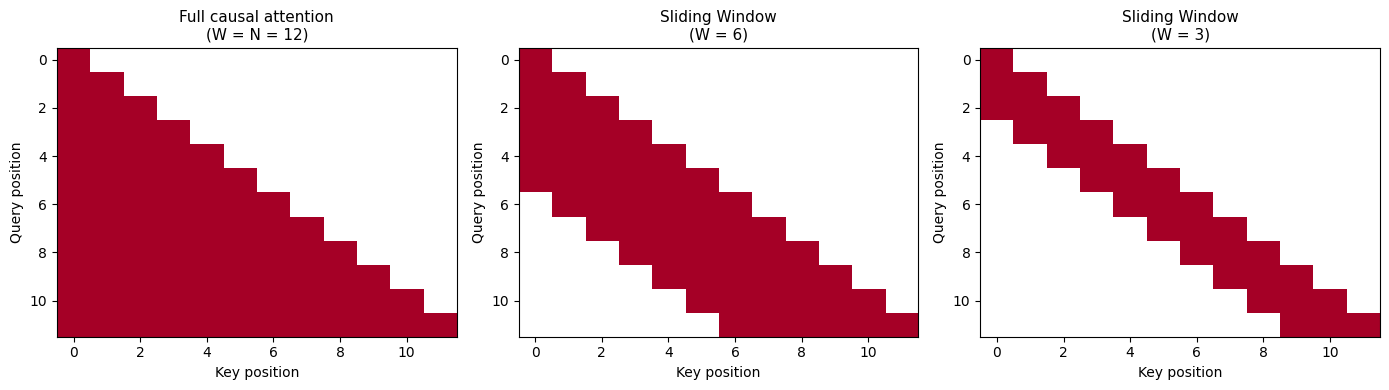

=== Sliding Window 计算量对比 ===

       N        标准 O(N²)       SW O(W·N)        减少
--------------------------------------------------
    4096      16,777,216      16,777,216      0.0%
    8192      67,108,864      33,554,432     50.0%
   32768   1,073,741,824     134,217,728     87.5%
  131072  17,179,869,184     536,870,912     96.9%

关键观察：
1. 窗口大小 W 固定时，计算量随 N 线性增长（O(W·N)），而非平方增长
2. 当 N >> W 时，节省的计算量非常显著
3. Sliding Window 也节省 KV Cache：每层只存 W 个 K,V，而不是 N 个
4. 代价是丢失长距离注意力——需要偶尔的 global attention 层来弥补


In [14]:
import torch
import matplotlib.pyplot as plt

def create_sliding_window_mask(seq_len, window_size):
    """
    构造 Sliding Window Attention 的 mask。

    每个 token i 只能关注 [i - window_size + 1, i] 范围内的 token，
    同时保留 causal mask（不能看未来）。

    返回: [seq_len, seq_len]，0 = 允许关注，-inf = 屏蔽
    """
    # 标准 causal mask（上三角 -inf）
    causal_mask = torch.triu(
        torch.full((seq_len, seq_len), float('-inf')), diagonal=1
    )

    # 找出距离超过窗口的历史位置
    row = torch.arange(seq_len).unsqueeze(1)  # [seq_len, 1]
    col = torch.arange(seq_len).unsqueeze(0)  # [1, seq_len]
    distance = row - col                      # [seq_len, seq_len]
    outside_window = distance > window_size - 1

    # 合并 causal + sliding window
    mask = causal_mask.clone()
    mask[outside_window] = float('-inf')

    return mask

# 演示：不同窗口大小的 mask
seq_len = 12
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax_idx, (w, title) in enumerate([
    (12, "Full causal attention\n(W = N = 12)"),
    (6,  "Sliding Window\n(W = 6)"),
    (3,  "Sliding Window\n(W = 3)"),
]):
    mask = create_sliding_window_mask(seq_len, w)
    ax = axes[ax_idx]
    # 绿色 = 可见，红色 = 不可见
    im = ax.imshow(mask, cmap='RdYlGn_r', aspect='auto', vmin=-10, vmax=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")

plt.tight_layout()
plt.show()

# 计算量对比
print("=== Sliding Window 计算量对比 ===")
print()
print(f"{'N':>8s}  {'标准 O(N²)':>14s}  {'SW O(W·N)':>14s}  {'减少':>8s}")
print("-" * 50)
for N in [4096, 8192, 32768, 131072]:
    W = 4096
    full_ops = N * N
    sw_ops = W * N
    reduction = (1 - sw_ops / full_ops) * 100
    print(f"{N:>8d}  {full_ops:>14,d}  {sw_ops:>14,d}  {reduction:>7.1f}%")

print()
print("关键观察：")
print("1. 窗口大小 W 固定时，计算量随 N 线性增长（O(W·N)），而非平方增长")
print("2. 当 N >> W 时，节省的计算量非常显著")
print("3. Sliding Window 也节省 KV Cache：每层只存 W 个 K,V，而不是 N 个")
print("4. 代价是丢失长距离注意力——需要偶尔的 global attention 层来弥补")


## 14. 规划 4K→32K 扩展

```text
1. 选择受支持的方案。
   可不改权重测试静态 NTK-aware，也可用 PI / YaRN 长文本适配配方。
2. 按真实 checkpoint 计算。
   仅作例子：base=10000，d=64，scale=8
   new_base = 10000 × 8^(64/62) ≈ 85549。
   检查旋转维度及已有 rope_scaling。
3. 同时验证长短上下文：捞针、多跳任务、held-out PPL。
4. 检索失败时检查数据和缩放，考虑微调；显存不足时检查 KV 量化与推理实现。
```

单个公式不能证明已经具备可用的 32K 能力。


## 15. 使用 ModelScope 查看上下文配置

加载 Qwen2.5-0.5B-Instruct，查看配置，计算候选 NTK base，再跑捞针流程。模型原本已有 32K 位置配置，下方 8K 测试在原生窗口以内。

这一节没有修改或重建已加载模型的旋转模块，因此不是扩展后的测评。缺少可选依赖时，ToyModel 只检查数据流，始终返回固定密码。


In [15]:
# === 可选实战依赖：transformers / modelscope ===
# 本 notebook 前半部分是纯手写原理演示；这一节如果缺少依赖，会自动切到 ToyModel。

import torch

try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from modelscope import snapshot_download
    HAS_REAL_LONG_CONTEXT_DEMO = True
except ModuleNotFoundError as e:
    AutoModelForCausalLM = AutoTokenizer = snapshot_download = None
    HAS_REAL_LONG_CONTEXT_DEMO = False
    print(f"可选依赖缺失: {e}")
    print("使用 ToyTokenizer/ToyModel 跑通后续流程；真实 Qwen 实战需安装 transformers + modelscope。")

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch: 2.8.0+rocm7.0.0.gitb2fb6885, CUDA: True


In [ ]:
# === 从 ModelScope 下载并加载 Qwen2.5-0.5B-Instruct ===
# 如果本地没有可选依赖或网络环境不可用，就用 ToyModel 保持 notebook 可执行。

import torch

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

if HAS_REAL_LONG_CONTEXT_DEMO:
    print("正在从 ModelScope 下载模型...")
    model_dir = snapshot_download(model_name, revision="master")
    print(f"模型下载到: {model_dir}\n")

    tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_dir,
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        device_map="auto" if DEVICE == "cuda" else None,
        trust_remote_code=True,
    )
    if DEVICE == "cpu":
        model = model.to(DEVICE)
    model.eval()
else:
    print("跳过真实模型下载，创建离线 ToyModel 用于演示数据流。")

    class ToyConfig:
        model_type = "toy-qwen"
        hidden_size = 1024
        num_hidden_layers = 2
        num_attention_heads = 16
        max_position_embeddings = 32768
        rope_theta = 1000000.0
        rope_scaling = None

    class ToyTokenizer:
        def __init__(self):
            self.eos_token_id = 0
            self.vocab = {"<eos>": 0}
            self.reverse = {0: ""}

        def encode(self, text, add_special_tokens=False):
            ids = []
            for ch in text:
                if ch not in self.vocab:
                    self.vocab[ch] = len(self.vocab)
                    self.reverse[self.vocab[ch]] = ch
                ids.append(self.vocab[ch])
            return ids

        def decode(self, ids, skip_special_tokens=False):
            return "".join(self.reverse.get(int(i), "") for i in ids)

        def apply_chat_template(self, messages, tokenize=False, add_generation_prompt=False):
            text = "".join(f"[{m['role']}] {m['content']}\n" for m in messages)
            if add_generation_prompt:
                text += "[assistant] "
            return self.encode(text, add_special_tokens=False) if tokenize else text

    class ToyModel:
        def __init__(self, tokenizer):
            self.config = ToyConfig()
            self.tokenizer = tokenizer

        def to(self, device):
            return self

        def eval(self):
            return self

        def generate(self, input_tensor, max_new_tokens=50, **kwargs):
            suffix = torch.tensor([self.tokenizer.encode("8842")], device=input_tensor.device)
            return torch.cat([input_tensor, suffix], dim=1)

    tokenizer = ToyTokenizer()
    model = ToyModel(tokenizer).to(DEVICE).eval()

print(f"模型类型: {model.config.model_type}")
print(f"隐藏维度: {model.config.hidden_size}")
print(f"层数: {model.config.num_hidden_layers}")
print(f"注意力头数: {model.config.num_attention_heads}")
print(f"max_position_embeddings: {model.config.max_position_embeddings}  ← 配置中的位置上限")
print(f"rope_theta: {model.config.rope_theta}  ← RoPE 的 base 值")
print(f"rope_scaling: {model.config.rope_scaling}  ← 是否已启用外推策略")


### 15.1 计算 NTK 扩展所需的 rope_theta

做 NTK 长上下文扩展时，为什么需要先算 rope_theta？因为它通过修改 base 值来压缩旋转频率，而新 base 必须提前算好才能改配置。具体的 NTK 公式如下：`新 base = 旧 base × scale^(d/(d-2))`。

那么 scale 是什么？它代表扩展倍数，定义为 `scale = 目标长度 / 原始长度`。

下面针对 Qwen2.5-0.5B 算几个常见扩展目标：

下面只计算候选参数，不应用到已加载模型，不能证明这些目标长度可用。


In [ ]:
# === 用 NTK 公式计算不同目标长度所需的 rope_theta ===
# Qwen2.5-0.5B 默认 max_position = 32768, rope_theta = 1000000

def ntk_rope_theta(original_base, original_len, target_len, d_k):
    """NTK-aware: 计算扩展后的 rope_theta"""
    scale = target_len / original_len
    new_base = original_base * (scale ** (d_k / (d_k - 2)))
    return new_base

# Qwen2.5-0.5B 的参数
d_k = model.config.hidden_size // model.config.num_attention_heads  # head_dim
original_base = model.config.rope_theta
original_len = model.config.max_position_embeddings

print(f"当前配置:")
print(f"  head_dim = {d_k}")
print(f"  rope_theta = {original_base:,}")
print(f"  max_position = {original_len:,} tokens")
print()

# 计算扩展到不同长度的 rope_theta
targets = {
    "64K": 65536,
    "128K": 131072,
    "256K": 262144,
    "1M": 1048576,
}

print("NTK 扩展表:")
print(f"{'目标长度':<10} {'scale':<10} {'新 rope_theta':<15} {'公式'}")
print("-" * 65)
for label, target in targets.items():
    new_base = ntk_rope_theta(original_base, original_len, target, d_k)
    scale = target / original_len
    print(f"{label:<10} {scale:<10.1f} {new_base:<15,.0f} base×{scale:.1f}^({d_k}/{d_k-2})")

print(f"\n操作：这些只是候选参数；应用配置需重新初始化旋转模块并验证")
print(f"  例: 32K→128K: 把 rope_theta 从 {original_base:,} 改为 {ntk_rope_theta(original_base, original_len, 131072, d_k):,.0f}")

### 15.2 Needle in a Haystack 验证

为什么要做 Needle in a Haystack 验证？因为我们得确认模型在长文本里是否真能找到藏起来的关键信息。做法很直接：构造一段长文本，中间藏一句话，看模型能否找出。

**测试设计**：
1. 生成一段“干草堆”——用无关文本填充到目标长度
2. 在指定位置插入“针”——一句关键信息
3. 问模型只有读针才能答的问题
4. 看模型能否正确回答

记录真实 Token 长度，模板与问题也占 Token。ToyModel 的固定答案只验证数据流。


In [ ]:
# === 大海捞针测试 ===

import torch

def build_needle_haystack(tokenizer, target_len, needle, needle_pos, question):
    """
    构造大海捞针测试

    参数:
        target_len: 目标 token 总数
        needle: 要藏的信息（字符串）
        needle_pos: 针的位置（0~1，0=开头，1=结尾）
        question: 提问的内容
    """
    # 干草堆：用一段循环的无关文本填充
    haystack_sentence = (
        "The quick brown fox jumps over the lazy dog. "
        "Machine learning is a subset of artificial intelligence. "
        "The weather today is quite pleasant with a gentle breeze blowing. "
        "Many people enjoy reading books and drinking coffee in the morning. "
    )

    # 编码干草堆文本，看每个 token 用多少
    haystack_tokens = tokenizer.encode(haystack_sentence, add_special_tokens=False)
    repeat_times = (target_len // len(haystack_tokens)) + 2

    # 构造完整文本：haystack + needle 插入 + haystack
    repeat_text = haystack_sentence * repeat_times
    full_tokens = tokenizer.encode(repeat_text, add_special_tokens=False)

    # 计算插入位置（token 级别）
    insert_idx = int(target_len * needle_pos)
    needle_tokens = tokenizer.encode(f"\n\n[重要信息]: {needle}\n\n", add_special_tokens=False)

    # 拼接
    prefix = full_tokens[:insert_idx]
    suffix = full_tokens[insert_idx:target_len - len(needle_tokens)]
    test_tokens = prefix + needle_tokens + suffix
    test_tokens = test_tokens[:target_len]

    # 构造 chat prompt
    test_text = tokenizer.decode(test_tokens)
    messages = [
        {"role": "system", "content": "你是一个帮助提取信息的助手。请根据上文内容简短回答。"},
        {"role": "user", "content": f"请阅读以下文本并回答问题。\n\n{test_text}\n\n问题：{question}"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt, tokenizer.encode(prompt, add_special_tokens=False)

# 测试参数
target_len = 8000  # 8K token 的测试文本（在默认 32K 窗口内）
needle = "打开保险箱的密码是 8842"
needle_pos = 0.5  # 放在中间位置
question = "保险箱的密码是什么？"

prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
print(f"测试文本长度: {len(input_ids)} tokens")
print(f"针的位置: {needle_pos*100:.0f}% (大约第 {int(target_len*needle_pos)} token)")
print(f"针的内容: '{needle}'")
print(f"问题: '{question}'")
print()

# 生成回答
input_tensor = torch.tensor([input_ids]).to(DEVICE)
with torch.no_grad():
    output = model.generate(
        input_tensor,
        max_new_tokens=50,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
print(f"模型回答: {answer.strip()}")
print()

# 检查是否答对
if "8842" in answer or "8842" in answer.replace(" ", ""):
    print("✅ 测试通过！当前模型或固定答案 ToyModel 返回了密码")
else:
    print("❌ 测试失败！模型没有正确找到针的信息")


### 15.3 不同深度的捞针测试

将针放在 0%、10%、25%、…、100% 深度，统计各位置正确性。中间失败是位置敏感性的线索，不能凭一个例子确认 Lost in the Middle；需比较首尾与中间的多次测试。边缘失败也不能单独归因于 RoPE。

下面使用已加载模型打印深度结果表，不绘制热力图。


In [ ]:
# === 全位置大海捞针测试 ===

import torch

def test_needle_at_position(target_len, needle, needle_pos, question):
    """在指定位置做一次捞针测试，返回是否成功"""
    prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
    input_tensor = torch.tensor([input_ids]).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            input_tensor,
            max_new_tokens=50,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
    # 宽松匹配：只要答出关键数字就行
    return "8842" in answer.replace(" ", "")

# 在默认 32K 窗口内，测试不同位置
positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
results = []

print(f"大海捞针测试: 文本长度={target_len} tokens")
print(f"{'Position':<12} {'结果':<8} {'说明'}")
print("-" * 40)

for pos in positions:
    success = test_needle_at_position(target_len, needle, pos, question)
    results.append(success)
    desc = ""
    if pos < 0.2:
        desc = "(开头 — 容易被看到)"
    elif pos > 0.8:
        desc = "(结尾 — recency bias)"
    else:
        desc = "(中间 — Lost in Middle 高危区)"
    print(f"{pos*100:3.0f}%位置    {'✅' if success else '❌'}      {desc}")

print()
success_rate = sum(results) / len(results)
print(f"成功率: {success_rate:.0%} ({sum(results)}/{len(results)})")

# 如果中间位置失败，说明存在 Lost in the Middle
mid_results = [r for p, r in zip(positions, results) if 0.15 < p < 0.85]
edge_results = [r for p, r in zip(positions, results) if p <= 0.15 or p >= 0.85]
if sum(mid_results) < len(mid_results):
    print(f"\n⚠ 中间位置出现失败 → 需要重复测试并与首尾对照")
    print(f"   边缘成功率: {sum(edge_results)}/{len(edge_results)}")
    print(f"   中间成功率: {sum(mid_results)}/{len(mid_results)}")


### 15.4 这个实验验证了什么

1. 使用 ModelScope 下载和加载模型。
2. 查看 rope_theta、max_position_embeddings 和已有缩放配置。
3. 用 $b'=b\,s^{d/(d-2)}$ 计算候选 base。
4. 在当前配置窗口内测试捞针。

若要真正扩展，应先将目标配置应用于另一个模型的旋转模块初始化，或用受支持的 API 重建模块，再比较原模型与改动模型在原窗口外的表现，也检查短上下文质量。

```bash
# 配置并验证之后，声明服务长度的例子：
# vllm serve <model-directory> --max-model-len 131072
```

这个参数不会训练模型，也不能自动建立 128K 能力。改 base 不改已学习权重，质量仍需实验确认。


## 小结

RoPE 逐对旋转 Q/K。固定内容向量时，点积中的显式位置项取决于相对位移，而非两个独立绝对位置。

各频率在训练中覆盖不同相位范围，外推带来新的联合相位与距离模式。慢维度角度是有用直觉，但不能证明快维度总能成功外推。

PI 统一压缩位置；静态 NTK-aware 改 base，让慢维度压缩更多；YaRN 混合频段并缩放 Attention。改配置本身不保证稳定质量。

捞针、RULER 和 held-out PPL 应联合使用。Lost in the Middle 需要对照测试；模拟曲线不是跑分。

KV 缓存随长度线性增，全 Attention 算术平方增。KV 量化、上下文并行、滑动窗口解决不同约束。

参考：[RoPE](https://arxiv.org/abs/2104.09864)、[PI](https://arxiv.org/abs/2306.15595)、[NTK-aware](https://www.reddit.com/r/LocalLLaMA/comments/14lz7j5/ntkaware_scaled_rope_allows_llama_models_to_have/)、[YaRN](https://arxiv.org/abs/2309.00071)、[LongRoPE](https://arxiv.org/abs/2402.13753)、[LongRoPE2](https://arxiv.org/abs/2502.20082)。


## 作业

> 可让 AI 帮忙解释思路，但不建议直接让 AI“做完这道题”。

### 作业 1：NTK-aware base 值计算

为什么要算这个作业？因为掌握 NTK-aware 的 base 值计算，是实际改 rope_theta 配置的前提。NTK-aware 方法通过修改 RoPE 的 base 参数实现外推，公式为：

$$\text{new\_base} = \text{old\_base} \times \text{scale}^{d/(d-2)}$$

假设原始 base = 10000，头维度 $d = 128$，要从 4K 扩展到 32K（scale = 8）。我们的任务就是计算新的 base 值。

**小提示**：$d/(d-2) = 128/126 \approx 1.016$，所以 $\text{new\_base} = 10000 \times 8^{1.016}$。

In [20]:
# 作业 1：NTK-aware base 值计算
import math

old_base = 10000
d = 128
scale = 8

# TODO: 计算指数 d/(d-2)
exponent = d / (d - 2)

# TODO: 计算新的 base 值
new_base = old_base * scale ** exponent

assert exponent is not None, "请先计算指数"
assert new_base is not None, "请先计算新 base"

expected_exp = d / (d - 2)
expected_base = old_base * (scale ** expected_exp)
assert abs(exponent - expected_exp) < 0.001, f"指数应为 {expected_exp:.4f}"
assert abs(new_base - expected_base) / expected_base < 0.01, f"新 base 应为 {expected_base:.0f}"

print("✅ 作业 1 通过：")
print(f"   指数 d/(d-2) = {exponent:.4f}")
print(f"   new_base = {new_base:.0f}")
print(f"   相比原始 base 增长了 {new_base/old_base:.1f}×")
print("   NTK 只改一个参数，就自动实现不同维度的差异化压缩。")

### 作业 2：RoPE 旋转角度计算

为什么要计算 RoPE 的旋转角度？因为只有明确每个位置对应的角度，才能看清旋转位置编码如何区分不同序列位置。RoPE 对每对维度施加旋转，角度为 $\theta = m / \text{base}^{2i/d}$，其中 $m$ 是位置编号，$i$ 是维度对的索引。

下面我们代入一组具体参数来算一次。假设 base = 10000，$d = 4$（共 2 对维度）。需要计算位置 $m = 0$ 和 $m = 100$ 时，第一对维度（$i=0$）的旋转角度。

先看一下指数部分。当 $i=0$ 时，指数 $2i/d$ 等于 0，因此 $\text{base}^{2i/d}$ 就是 $10000^{0}$，数值为 1。换句话说，旋转角度等于位置编号 $m$ 除以 1，也就是 $m$ 弧度。那么 $m=0$ 时角度为 0 弧度，$m=100$ 时角度为 100 弧度。

**小提示**：$\theta_{i=0} = m / \text{base}^{0} = m$（弧度），所以 $m=100$ 时 $\theta = 100$ 弧度。

In [21]:
# 作业 2：RoPE 旋转角度计算
import math

base = 10000
d = 4
i = 0

# TODO: 计算位置 m=0 时的旋转角度
theta_m0 = 0 / (base ** (2 * i / d))

# TODO: 计算位置 m=100 时的旋转角度
theta_m100 = 100 / (base ** (2 * i / d))

assert theta_m0 is not None, "请先计算 m=0 的角度"
assert theta_m100 is not None, "请先计算 m=100 的角度"

expected_0 = 0 / (base ** (2 * i / d))
expected_100 = 100 / (base ** (2 * i / d))
assert abs(theta_m0 - expected_0) < 0.001, f"m=0 角度应为 {expected_0}"
assert abs(theta_m100 - expected_100) / max(expected_100, 0.001) < 0.01, f"m=100 角度应为 {expected_100:.4f}"

print("✅ 作业 2 通过：")
print(f"   m=0:   θ = {theta_m0:.4f} rad（起点，无旋转）")
print(f"   m=100: θ = {theta_m100:.4f} rad（转了约 {theta_m100/(2*math.pi):.1f} 圈）")
theta_slow = 100 / (base ** (2 * 1 / d))
print(f"   对比：i=1 时 m=100: θ = {theta_slow:.6f} rad（几乎没转）")
print("   快维度（i=0）区分相邻位置，慢维度（i=1）承载远程关系。")

### 作业 3：PI 与 NTK-aware

4K→32K 时，PI 将每个位置除以 8；静态 NTK-aware 改 base，让不同频率对压缩比例不同。判断：

> 「PI 同比缩放所有频率对，减小局部相位间隔；NTK-aware 保持最快一对不变，让较慢维度逐渐压缩更多。」

提示：观察指数 2i/d。这描述位置公式，不保证短上下文任务精度全部保留。


In [ ]:
# 作业 3：PI 与 NTK 外推策略对比

# TODO: 判断说法是否正确，填入 True 或 False
answer = True

assert answer is not None, "请填入 True 或 False"
assert isinstance(answer, bool), "请填入 True 或 False"

if answer:
    print("✅ 作业 3 通过：")
    print("   PI 将所有位置除以 scale，不同维度对承受相同的压缩比。")
    print("   近程位置（如 0 和 1）的相对距离被缩小了 scale 倍，分辨力下降。")
    print("   NTK-aware 修改 base，快维度（高频）几乎不受影响，保持近程精度；")
    print("   慢维度（低频）被压缩更多，改变相位范围；质量仍需验证。")
else:
    print("这个说法是正确的。再想想 PI 和 NTK 各自对不同频率维度的影响。")